### **HAPLOTYPE CLUSTERING WITHOUT PHENOTYPE DATA**

 This workflow performs PCA and hierarchical clustering using interval-specific variation data. Accessions are coloured according to their assigned cluster because phenotype information is not available.

In [2]:
import os
import re
from datetime import date
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from adjustText import adjust_text

###### =============================================================================
##### INPUT DIRECTORY AND FILE SELECTION
###### =============================================================================

In [3]:
# Directory containing the interval-specific Excel files.
workDir="/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis"
datDir = f"{workDir}/extractedTraitIntervalTables/"

# List all Excel files in the directory.
files = sorted(
    [
        f for f in os.listdir(datDir)
        if f.endswith(".xlsx") and not f.startswith("~$")
    ]
)

In [4]:
# Display the available files and their corresponding indices.
for file_index, filename in enumerate(files):
    print(f"{file_index}: {filename}")

0: Dabbi_dth_2B_7719365_7814565_IBSpy_7700000_7850000.xlsx
1: Dabbi_dth_6A_19773127_19961633_IBSpy_19750000_20000000.xlsx
2: Dabbi_dth_8B_7925057_8153073_IBSpy_7900000_8200000.xlsx
3: Dabbi_dth_9A_6126196_6263250_IBSpy_6100000_6300000.xlsx
4: Dabbi_panLen_1A_6416669_6933524_IBSpy_6400000_6950000.xlsx
5: Dabbi_panLen_2A_4433713_4675660_IBSpy_4400000_4700000.xlsx
6: Dabbi_panLen_2B_25700018_25795218_IBSpy_25700000_25800000.xlsx
7: Dabbi_panLen_3A_4129008_4227350_IBSpy_4100000_4250000.xlsx
8: Dabbi_panLen_3B_2638730_2806858_IBSpy_2600000_2850000.xlsx
9: Dabbi_panLen_4A_7106186_7277839_IBSpy_7100000_7300000.xlsx
10: Dabbi_panLen_6B_7763900_8051348_IBSpy_7750000_8100000.xlsx
11: Dabbi_panLen_7B_1903398_2121900_IBSpy_1900000_2150000.xlsx
12: Dabbi_panShap_10A_2479547_2604219_IBSpy_2450000_2650000.xlsx
13: Dabbi_panShap_1B_23249295_23355755_IBSpy_23200000_23400000.xlsx
14: Dabbi_panShap_2A_24741867_25141867_IBSpy_24700000_25150000.xlsx
15: Dabbi_panShap_2A_24824087_25059647_IBSpy_24800000_251

In [5]:
# Select one file for analysis.
idx = 37
f = files[idx]

filepath = os.path.join(datDir, f)
INPUT_FILE = filepath

#### EXTRACT METADATA FROM THE FILENAME

Expected filename structure:

`reference_trait_chromosome_start_end.xlsx`

The pattern also accepts filenames containing rounded IBSpy coordinates:

`reference_trait_chromosome_start_end_IBSpy_roundedStart_roundedEnd.xlsx`

In [9]:
match = re.match(
    r"(?P<genome>[^_]+)_"
    r"(?P<trait>[^_]+)_"
    r"(?P<chromosome>[A-Za-z0-9]+)_"
    r"(?P<start>\d+)_"
    r"(?P<end>\d+)"
    r"(?:_IBSpy_(?P<rounded_start>\d+)_(?P<rounded_end>\d+))?"
    r"(?:_duplicate\d+)?"
    r"\.xlsx$",
    f
)

if not match:
    raise ValueError(
        "Filename does not match the expected structure: "
        "reference_trait_chromosome_start_end.xlsx"
    )

genome = match.group("genome")
trait = match.group("trait")
chromosome = match.group("chromosome")
start_pos = int(match.group("start"))
end_pos = int(match.group("end"))

# Retrieve rounded IBSpy coordinates when they are included in the filename.
rounded_start = match.group("rounded_start")
rounded_end = match.group("rounded_end")

if rounded_start is not None and rounded_end is not None:
    analysis_start = int(rounded_start)
    analysis_end = int(rounded_end)
else:
    analysis_start = start_pos
    analysis_end = end_pos

print(f"\nProcessing file: {f}")
print(f"File path: {filepath}")
print(f"Reference genome: {genome}")
print(f"Trait: {trait}")
print(f"Chromosome: {chromosome}")
print(f"Original interval: {start_pos:,}-{end_pos:,} bp")
print(f"Analysed interval: {analysis_start:,}-{analysis_end:,} bp")


Processing file: Quncho_panShap_2A_26980060_27365307_IBSpy_26950000_27400000.xlsx
File path: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/extractedTraitIntervalTables/Quncho_panShap_2A_26980060_27365307_IBSpy_26950000_27400000.xlsx
Reference genome: Quncho
Trait: panShap
Chromosome: 2A
Original interval: 26,980,060-27,365,307 bp
Analysed interval: 26,950,000-27,400,000 bp


In [10]:
# Create an interval-specific directory for output tables and figures.
outDir = os.path.join(
    workDir,
    f"{genome}/{genome}-{trait}-{chromosome}-{start_pos}-{end_pos}"
)

os.makedirs(outDir, exist_ok=True)

print(f"Output directory: {outDir}")

Output directory: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-panShap-2A-26980060-27365307


In [11]:
# =============================================================================
# FIGURE AND ANALYSIS LABELS
# =============================================================================

analysis_date = date.today()

target = (
    f"{analysis_start / 1e6:.2f}-"
    f"{analysis_end / 1e6:.2f}Mb"
)

In [12]:
# =============================================================================
# LOAD THE VARIATION DATA
#
# The first column is expected to contain accession identifiers. All remaining
# columns should contain numeric variation measurements for the interval.
# =============================================================================

df = pd.read_excel(INPUT_FILE)

# Use the first column as the accession identifier.
df = df.set_index(df.columns[0])

# Ensure accession identifiers are strings.
df.index = df.index.astype(str).str.strip()

# Confirm that accession names are unique.
if not df.index.is_unique:
    duplicated_accessions = df.index[df.index.duplicated()].unique()

    raise ValueError(
        "Duplicate accession identifiers were detected: "
        + ", ".join(duplicated_accessions)
    )

# Convert all variation columns to numeric values. Values that cannot be
# converted are represented as missing values.
variation_df = df.apply(pd.to_numeric, errors="coerce")

print(f"Number of accessions loaded: {variation_df.shape[0]}")
print(f"Number of variation variables loaded: {variation_df.shape[1]}")
print(variation_df.head())


Number of accessions loaded: 177
Number of variation variables loaded: 10
          26950000  27000000  27050000  27100000  27150000  27200000  \
Name                                                                   
teff_100         7         5         7         1        12         2   
teff_102       210       141       229       105        18         5   
teff_103        11         5        16         6       166       181   
teff_104         4         1         5         1        12         0   
teff_106         4         3        10        11        25         4   

          27250000  27300000  27350000  27400000  
Name                                              
teff_100         3         1         4         0  
teff_102         2       113        14        74  
teff_103        93        93        36         6  
teff_104         1         2         3         2  
teff_106         4         3        10        80  


In [13]:
# =============================================================================
# DATA QUALITY CONTROL
# =============================================================================

# Remove columns that contain no numeric observations.
all_missing_columns = variation_df.columns[
    variation_df.isna().all()
]

if len(all_missing_columns) > 0:
    print(
        f"Removing {len(all_missing_columns)} columns containing only "
        "missing values."
    )

    variation_df = variation_df.drop(
        columns=all_missing_columns
    )

# Replace remaining missing values with the median of the corresponding
# variation column.
variation_df = variation_df.fillna(
    variation_df.median()
)

# Remove invariant columns because they contain no information for PCA or
# clustering.
variable_columns = variation_df.columns[
    variation_df.nunique(dropna=False) > 1
]

removed_invariant = (
    variation_df.shape[1] - len(variable_columns)
)

if removed_invariant > 0:
    print(
        f"Removing {removed_invariant} invariant variation columns."
    )

variation_df = variation_df.loc[:, variable_columns]

# Stop the analysis if no informative variation columns remain.
if variation_df.shape[1] == 0:
    raise ValueError(
        "No variable numeric columns remain after data filtering."
    )

# Stop the analysis if fewer than two accessions are available.
if variation_df.shape[0] < 2:
    raise ValueError(
        "At least two accessions are required for clustering."
    )

print(
    f"Variation matrix used for clustering: "
    f"{variation_df.shape[0]} accessions × "
    f"{variation_df.shape[1]} variables"
)

Variation matrix used for clustering: 177 accessions × 10 variables


In [14]:
# =============================================================================
# STANDARDISATION AND PCA
# =============================================================================

# Convert the filtered variation table to a numeric matrix.
X = variation_df.to_numpy(dtype=float)

# Standardise each variable to a mean of zero and standard deviation of one.
X_scaled = StandardScaler().fit_transform(X)

# Retain the number of principal components required to explain at least 90%
# of the total variation.
pca = PCA(n_components=0.90)

PCs = pca.fit_transform(X_scaled)

print(
    f"PCA reduced the data to {PCs.shape[1]} components, explaining "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}% of the variation."
)

PCA reduced the data to 4 components, explaining 92.57% of the variation.


In [15]:
# =============================================================================
# HIERARCHICAL CLUSTERING
# =============================================================================

# Generate the hierarchical clustering linkage matrix using Ward's method.
linked = linkage(
    PCs,
    method="ward"
)

# Define the required number of accession clusters, based on the PCA components
k = 5

if k < 2:
    raise ValueError(
        "The number of clusters must be at least 2."
    )

if k > variation_df.shape[0]:
    raise ValueError(
        f"The number of clusters ({k}) cannot exceed the number of "
        f"accessions ({variation_df.shape[0]})."
    )

# Assign each accession to one of the k clusters.
agg = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

# Add one so that cluster identifiers begin at 1 rather than 0.
clusters = agg.fit_predict(PCs) + 1

cluster_column = f"cluster-{chromosome}"

# Add cluster assignments to a copy of the original input table.
results_df = df.copy()
results_df[cluster_column] = clusters

###### =============================================================================
#### EXPLORE POSSIBLE DENDROGRAM CUT HEIGHTS
###### =============================================================================

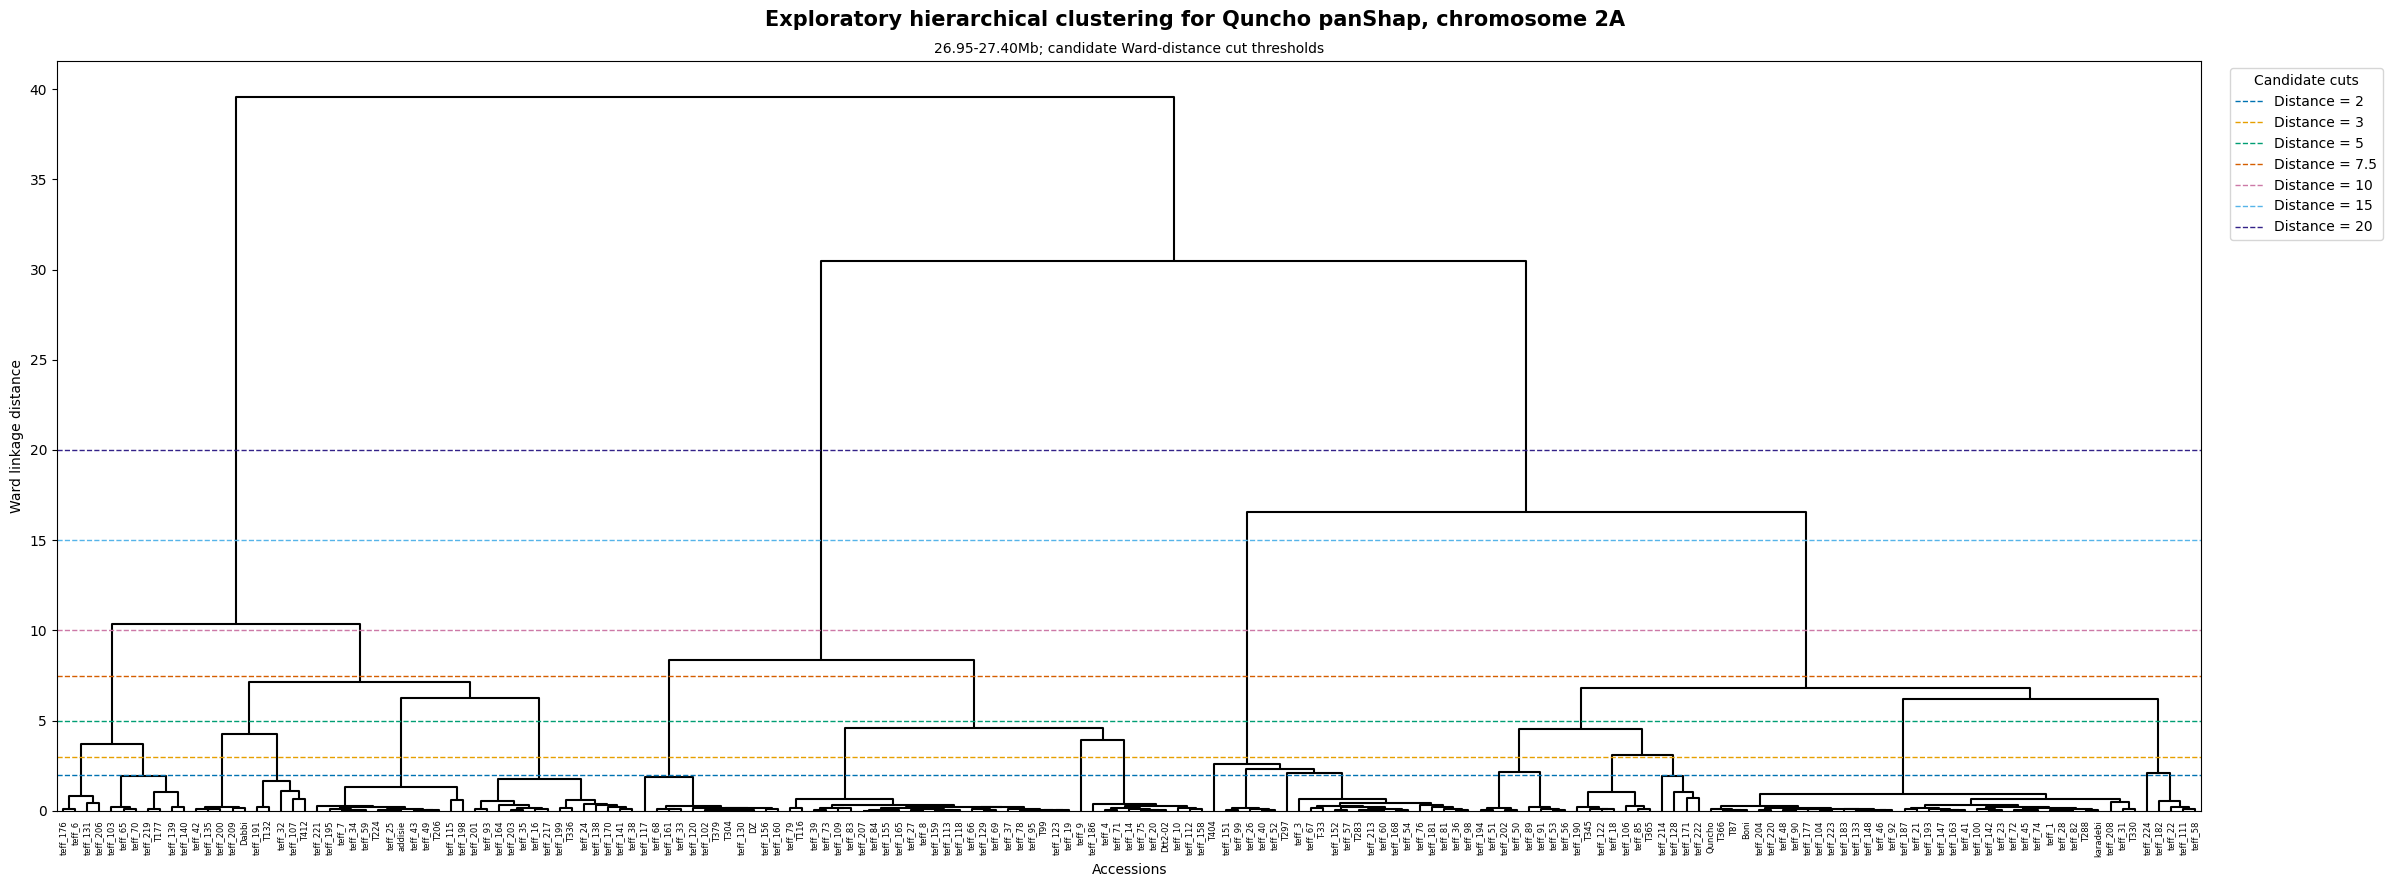

In [16]:
# The linkage matrix has already been calculated using:
#
# linked = linkage(PCs, method="ward")

plt.figure(figsize=(24, 9))

dendrogram(
    linked,
    labels=variation_df.index.astype(str),
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0,
    above_threshold_color="black"
)

# Add candidate Ward-distance thresholds for visual inspection.
# Modify these values according to the range of the dendrogram.
candidate_thresholds = [2, 3, 5, 7.5, 10, 15, 20]

candidate_line_colours = [
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#D55E00",
    "#CC79A7",
    "#56B4E9",
    "#332288",  # indigo
]

for threshold, line_colour in zip(
    candidate_thresholds,
    candidate_line_colours
):
    plt.axhline(
        y=threshold,
        color=line_colour,
        linestyle="--",
        linewidth=1,
        label=f"Distance = {threshold}"
    )

plt.suptitle(
    f"Exploratory hierarchical clustering for "
    f"{genome} {trait}, chromosome {chromosome}",
    fontsize=15,
    weight="bold"
)

plt.title(
    f"{target}; candidate Ward-distance cut thresholds",
    fontsize=10
)

plt.xlabel("Accessions")
plt.ylabel("Ward linkage distance")

plt.legend(
    title="Candidate cuts",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        outDir,
        f"{analysis_date}_{genome}_{trait}_{chromosome}_"
        f"{target}_cut_explorDendo.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()



With the above, we try a cut distance of five

In [17]:
cut_threshold = 5

In [18]:
# =============================================================================
# ASSIGN CLUSTERS USING A DENDROGRAM DISTANCE THRESHOLD
# =============================================================================

from scipy.cluster.hierarchy import fcluster

# Select the Ward linkage distance at which the dendrogram will be cut.
# Change this value after visually inspecting the exploratory dendrogram.

# Assign clusters by cutting the hierarchical tree at the selected distance.
clusters_raw = fcluster(
    linked,
    t=cut_threshold,
    criterion="distance"
)

# -------------------------------------------------------------------------
# Relabel clusters according to their left-to-right order in the dendrogram.
#
# fcluster cluster numbers are valid but are not necessarily assigned in an
# intuitive visual order. This step makes the leftmost cluster Cluster 1,
# followed by Cluster 2, and so on.
# -------------------------------------------------------------------------

dendro_order = dendrogram(
    linked,
    no_plot=True
)["leaves"]

cluster_order = []

for leaf_index in dendro_order:
    cluster_id = clusters_raw[leaf_index]

    if cluster_id not in cluster_order:
        cluster_order.append(cluster_id)

cluster_relabel_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(
        cluster_order,
        start=1
    )
}

clusters = np.array(
    [
        cluster_relabel_map[cluster_id]
        for cluster_id in clusters_raw
    ]
)

number_of_clusters = len(np.unique(clusters))

print(
    f"Cutting the dendrogram at Ward distance {cut_threshold} "
    f"produced {number_of_clusters} clusters."
)

cluster_column = f"cluster-{chromosome}"

# Add the final threshold-derived cluster assignments to the results table.
results_df = df.copy()
results_df[cluster_column] = clusters

print("\nNumber of accessions in each cluster:")
print(
    results_df[cluster_column]
    .value_counts()
    .sort_index()
)

Cutting the dendrogram at Ward distance 5 produced 10 clusters.

Number of accessions in each cluster:
1     11
2     10
3     13
4     14
5     12
6     35
7     22
8     19
9     36
10     5
Name: cluster-2A, dtype: int64


In [19]:
# =============================================================================
# DEFINE ONE COLOUR FOR EACH THRESHOLD-DERIVED CLUSTER
# =============================================================================

# High-contrast palette for up to 20 clusters.
cluster_colours = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#000000",  # black
    "#332288",  # indigo
    "#661100",  # dark brown
    "#888888",  # grey
    "#44AA99",  # teal
    "#882255",  # wine
    "#117733",  # dark green
    "#999933",  # olive
    "#AA4499",  # purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#88CCEE",  # light blue
    "#DDCC77",  # sand
    "#CC6677",  # muted red
    "#6699CC",  # steel blue
    "#661100",  # dark brown
    "#888888",  # grey
]

if number_of_clusters > len(cluster_colours):
    raise ValueError(
        f"The selected dendrogram cut produced "
        f"{number_of_clusters} clusters, but the palette contains only "
        f"{len(cluster_colours)} colours."
    )

cluster_color_map = {
    cluster_id: cluster_colours[cluster_id - 1]
    for cluster_id in range(1, number_of_clusters + 1)
}

sample_to_cluster = dict(
    zip(results_df.index.astype(str), clusters)
)

print("\nCluster colour assignments:")

for cluster_id, colour in cluster_color_map.items():
    print(f"Cluster {cluster_id}: {colour}")


Cluster colour assignments:
Cluster 1: #0072B2
Cluster 2: #E69F00
Cluster 3: #009E73
Cluster 4: #CC79A7
Cluster 5: #000000
Cluster 6: #332288
Cluster 7: #661100
Cluster 8: #888888
Cluster 9: #44AA99
Cluster 10: #882255


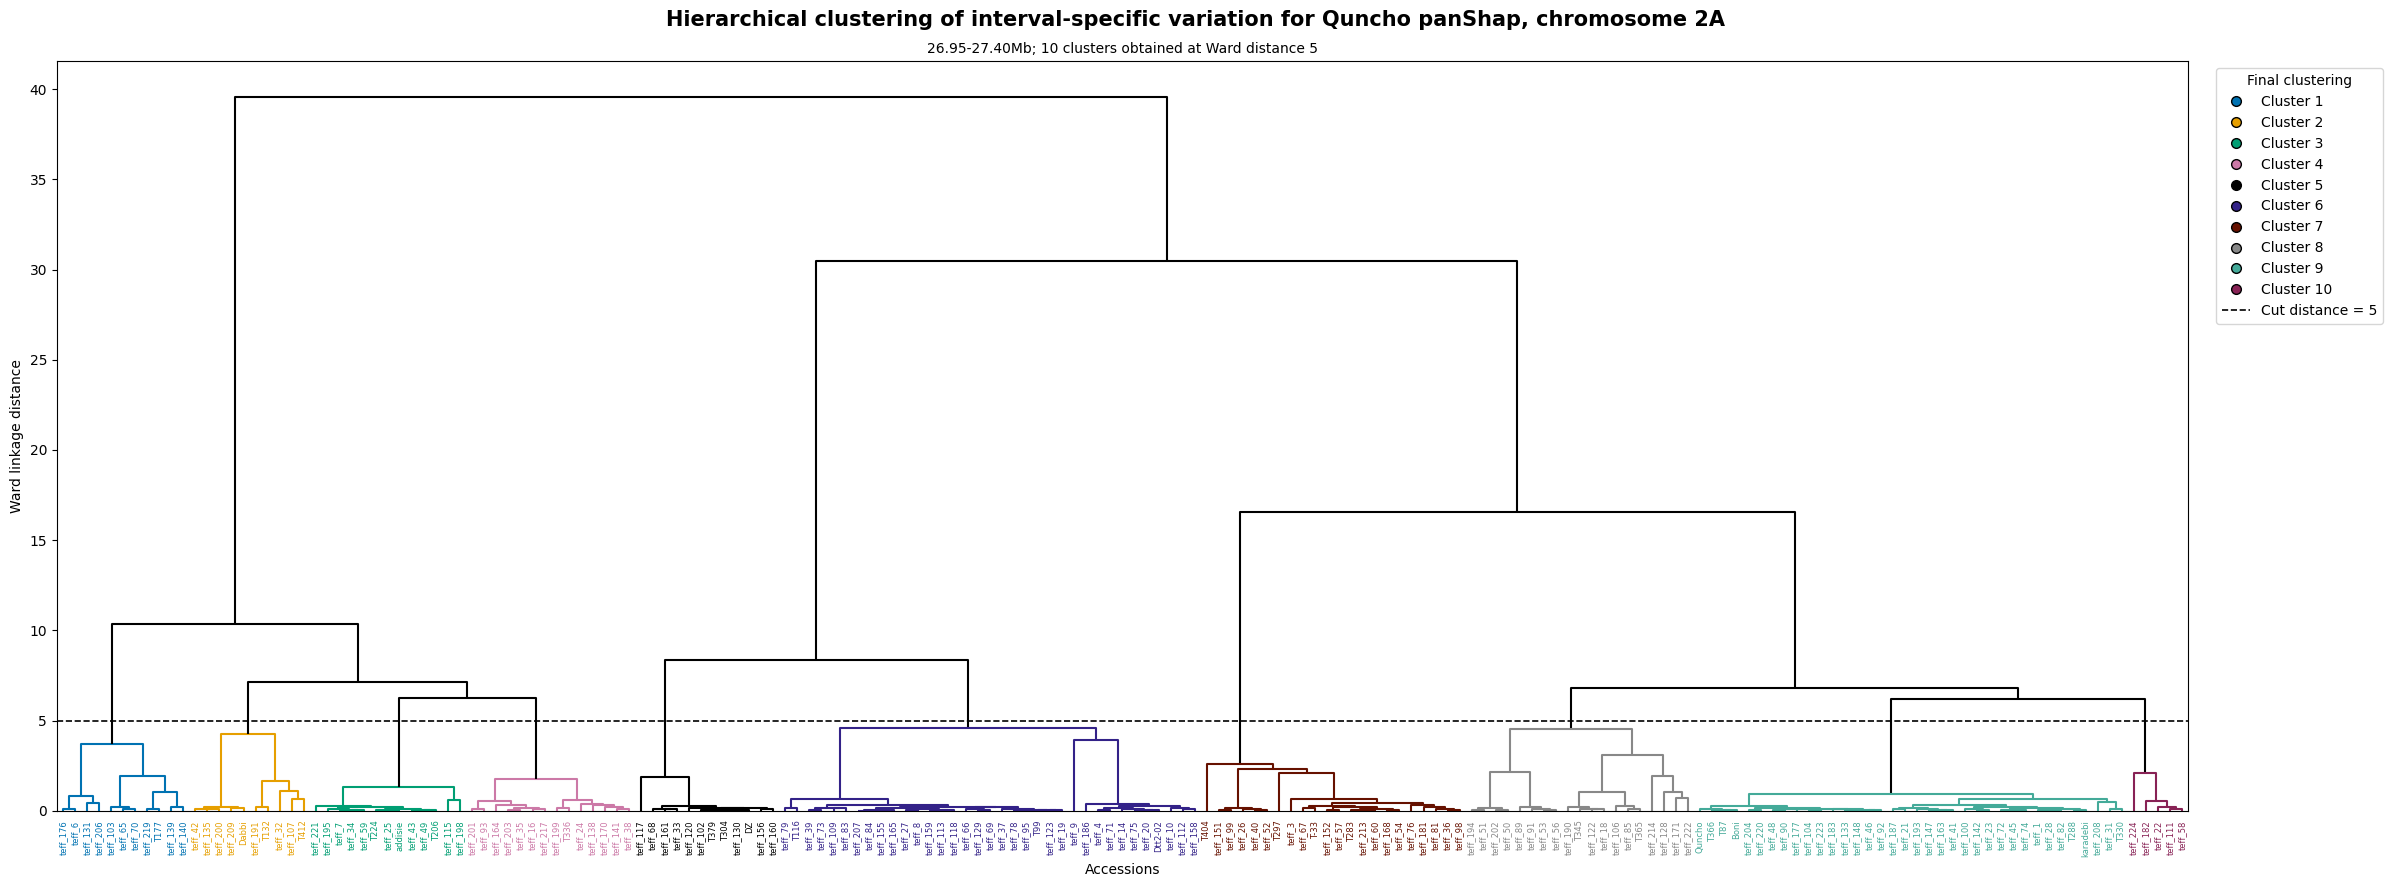

In [20]:
# =============================================================================
# REPLOT THE DENDROGRAM USING THE SELECTED CUT AND CLUSTER COLOURS
# =============================================================================

number_of_accessions = len(results_df)

# Store the descendant leaves associated with every node in the linkage tree.
descendant_cache = {
    leaf_index: [leaf_index]
    for leaf_index in range(number_of_accessions)
}


def get_descendant_leaves(node_id):
    """
    Return all original leaf indices descending from a linkage-tree node.
    """

    node_id = int(node_id)

    if node_id in descendant_cache:
        return descendant_cache[node_id]

    linkage_row = node_id - number_of_accessions

    left_child = int(linked[linkage_row, 0])
    right_child = int(linked[linkage_row, 1])

    descendant_leaves = (
        get_descendant_leaves(left_child)
        + get_descendant_leaves(right_child)
    )

    descendant_cache[node_id] = descendant_leaves

    return descendant_leaves


def dendrogram_branch_colour(node_id):
    """
    Colour a dendrogram branch by cluster when all descendant accessions
    belong to the same final cluster. Mixed-cluster branches are black.
    """

    descendant_leaves = get_descendant_leaves(node_id)

    descendant_clusters = np.unique(
        clusters[descendant_leaves]
    )

    if len(descendant_clusters) == 1:
        cluster_id = int(descendant_clusters[0])
        return cluster_color_map[cluster_id]

    return "#000000"


plt.figure(figsize=(24, 9))

ddata = dendrogram(
    linked,
    labels=results_df.index.astype(str),
    leaf_rotation=90,
    leaf_font_size=6,
    link_color_func=dendrogram_branch_colour,
    above_threshold_color="black"
)

# Draw the selected dendrogram cut.
plt.axhline(
    y=cut_threshold,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Selected cut = {cut_threshold}"
)

ax = plt.gca()

# Colour accession labels according to their final cluster assignment.
for label in ax.get_xmajorticklabels():
    accession = label.get_text()
    cluster_id = sample_to_cluster[accession]

    label.set_color(
        cluster_color_map[cluster_id]
    )

# Construct a legend using the same cluster colours as the PCA.
cluster_legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=cluster_color_map[cluster_id],
        markeredgecolor="black",
        markersize=7,
        label=f"Cluster {cluster_id}"
    )
    for cluster_id in range(1, number_of_clusters + 1)
]

cut_line_handle = plt.Line2D(
    [0],
    [0],
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut distance = {cut_threshold}"
)

plt.suptitle(
    f"Hierarchical clustering of interval-specific variation for "
    f"{genome} {trait}, chromosome {chromosome}",
    fontsize=15,
    weight="bold"
)

plt.title(
    f"{target}; {number_of_clusters} clusters obtained at "
    f"Ward distance {cut_threshold}",
    fontsize=10
)

plt.xlabel("Accessions")
plt.ylabel("Ward linkage distance")

plt.legend(
    handles=cluster_legend_handles + [cut_line_handle],
    title="Final clustering",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        outDir,
        f"{analysis_date}_{genome}_{trait}_{chromosome}_"
        f"{target}_dendrogram_cut_{cut_threshold}.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

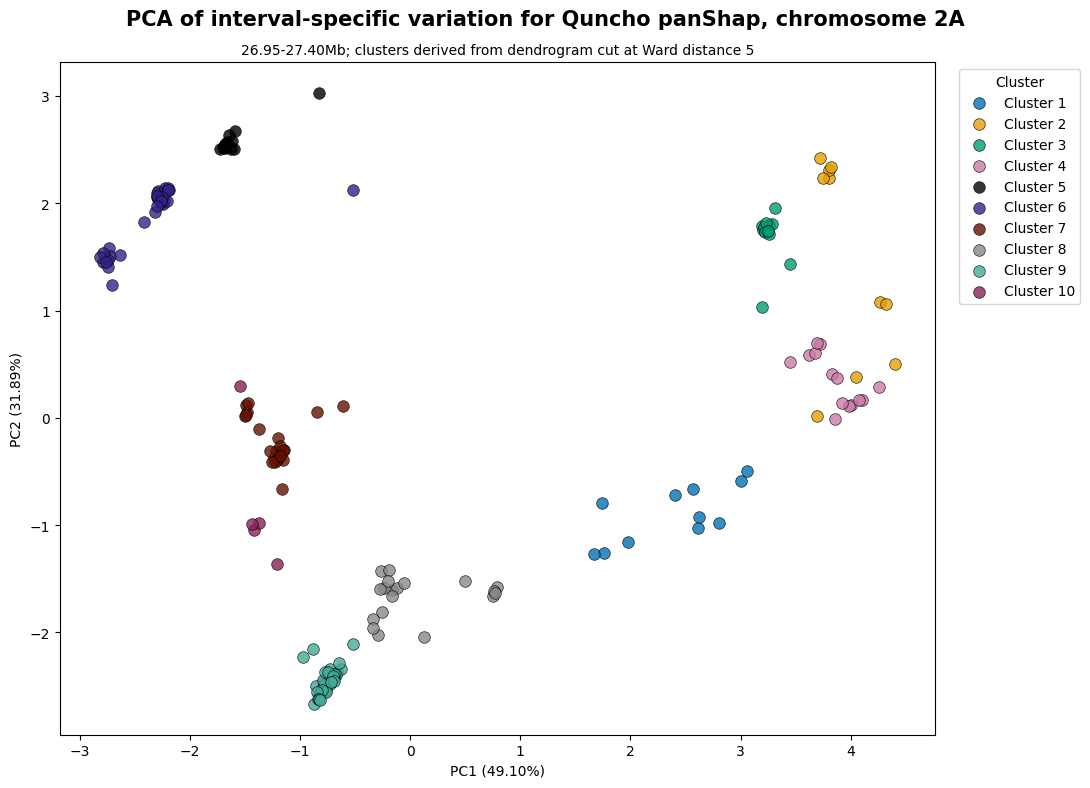

In [21]:
# =============================================================================
# PCA PLOT USING THE DENDROGRAM-DERIVED CLUSTERS
# =============================================================================

if PCs.shape[1] >= 2:

    plt.figure(figsize=(11, 8))

    for cluster_id in range(1, number_of_clusters + 1):

        cluster_mask = clusters == cluster_id

        plt.scatter(
            PCs[cluster_mask, 0],
            PCs[cluster_mask, 1],
            color=cluster_color_map[cluster_id],
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
            s=70,
            label=f"Cluster {cluster_id}"
        )

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
    )

    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
    )

    plt.suptitle(
        f"PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    plt.title(
        f"{target}; clusters derived from dendrogram cut at "
        f"Ward distance {cut_threshold}",
        fontsize=10
    )

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PCA_cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

###### =============================================================================
#### FUNCTION TO PLOT ANY TWO PRINCIPAL COMPONENTS
###### =============================================================================
The PCA doesnet seem to separate the clusters well andsome look like they overlap.
Below testing various PCA combination to check which is the best




In [268]:
def plot_pca_pair(
    PCs,
    pca,
    clusters,
    unique_clusters,
    cluster_color_map,
    pc_x,
    pc_y,
    genome,
    trait,
    chromosome,
    target,
    cut_threshold,
    outDir,
    analysis_date
):
    """
    Plot any pair of principal components using the final cluster assignments.

    Parameters
    ----------
    pc_x, pc_y : int
        Zero-based principal-component indices.
        For example:
            PC1 = 0
            PC2 = 1
            PC3 = 2
    """

    # Confirm that the requested principal components exist.
    if PCs.shape[1] <= max(pc_x, pc_y):
        print(
            f"Cannot plot PC{pc_x + 1} against PC{pc_y + 1}: "
            f"only {PCs.shape[1]} principal components were retained."
        )
        return

    plt.figure(figsize=(11, 8))

    for cluster_id in unique_clusters:
        cluster_mask = clusters == cluster_id

        plt.scatter(
            PCs[cluster_mask, pc_x],
            PCs[cluster_mask, pc_y],
            color=cluster_color_map[cluster_id],
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
            s=70,
            label=f"Cluster {cluster_id}"
        )

    # Add the percentage of variance explained by each displayed component.
    plt.xlabel(
        f"PC{pc_x + 1} "
        f"({pca.explained_variance_ratio_[pc_x] * 100:.2f}%)"
    )

    plt.ylabel(
        f"PC{pc_y + 1} "
        f"({pca.explained_variance_ratio_[pc_y] * 100:.2f}%)"
    )

    plt.suptitle(
        f"PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    plt.title(
        f"{target}; clusters derived from dendrogram cut at "
        f"Ward distance {cut_threshold}",
        fontsize=10
    )

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PC{pc_x + 1}_PC{pc_y + 1}_"
            f"cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [269]:
# Assign clusters from the selected dendrogram cut.
clusters_raw = fcluster(
    linked,
    t=cut_threshold,
    criterion="distance"
)

# Relabel clusters into consecutive numbers starting from 1.
dendro_order = dendrogram(
    linked,
    no_plot=True
)["leaves"]

cluster_order = []

for leaf_index in dendro_order:
    cluster_id = clusters_raw[leaf_index]

    if cluster_id not in cluster_order:
        cluster_order.append(cluster_id)

cluster_relabel_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(
        cluster_order,
        start=1
    )
}

clusters = np.array(
    [
        cluster_relabel_map[cluster_id]
        for cluster_id in clusters_raw
    ]
)

# Get the sorted cluster identifiers present in the final assignments.
unique_clusters = sorted(np.unique(clusters))

# Number of clusters generated by the selected cut.
number_of_clusters = len(unique_clusters)

print(f"Unique clusters: {unique_clusters}")
print(f"Number of clusters: {number_of_clusters}")

Unique clusters: [1, 2, 3, 4, 5, 6]
Number of clusters: 6


In [270]:
cluster_color_map = {
    cluster_id: cluster_colours[i]
    for i, cluster_id in enumerate(unique_clusters)
}

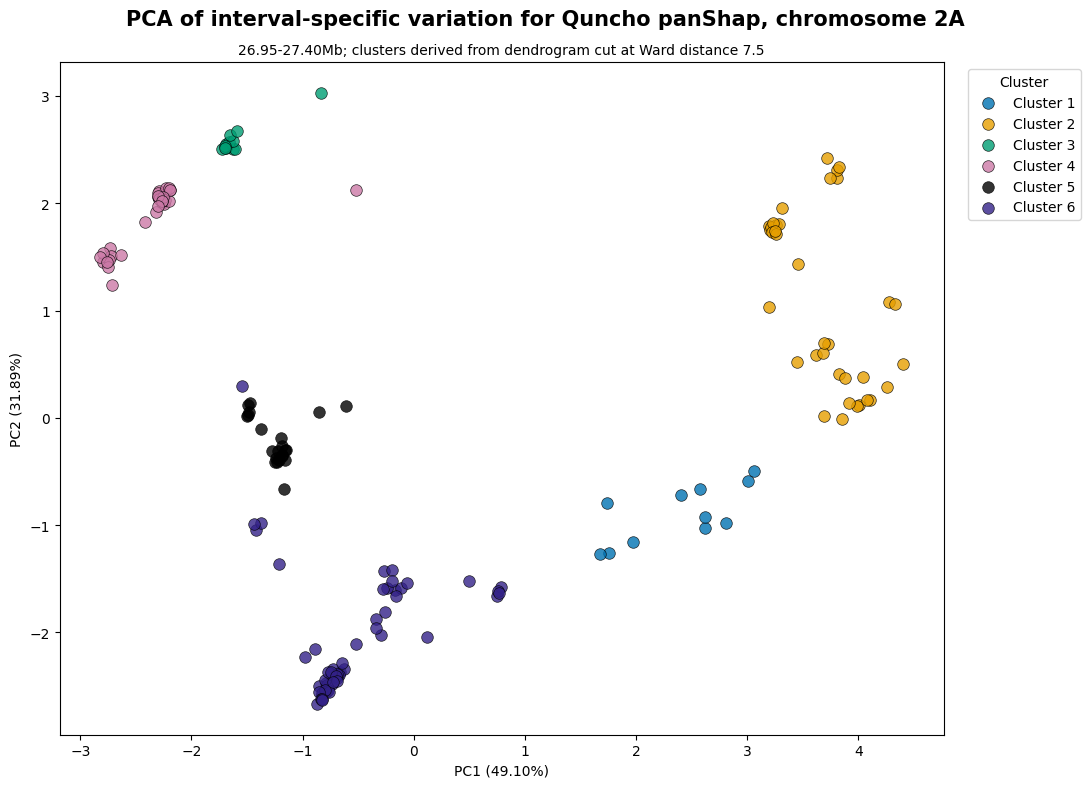

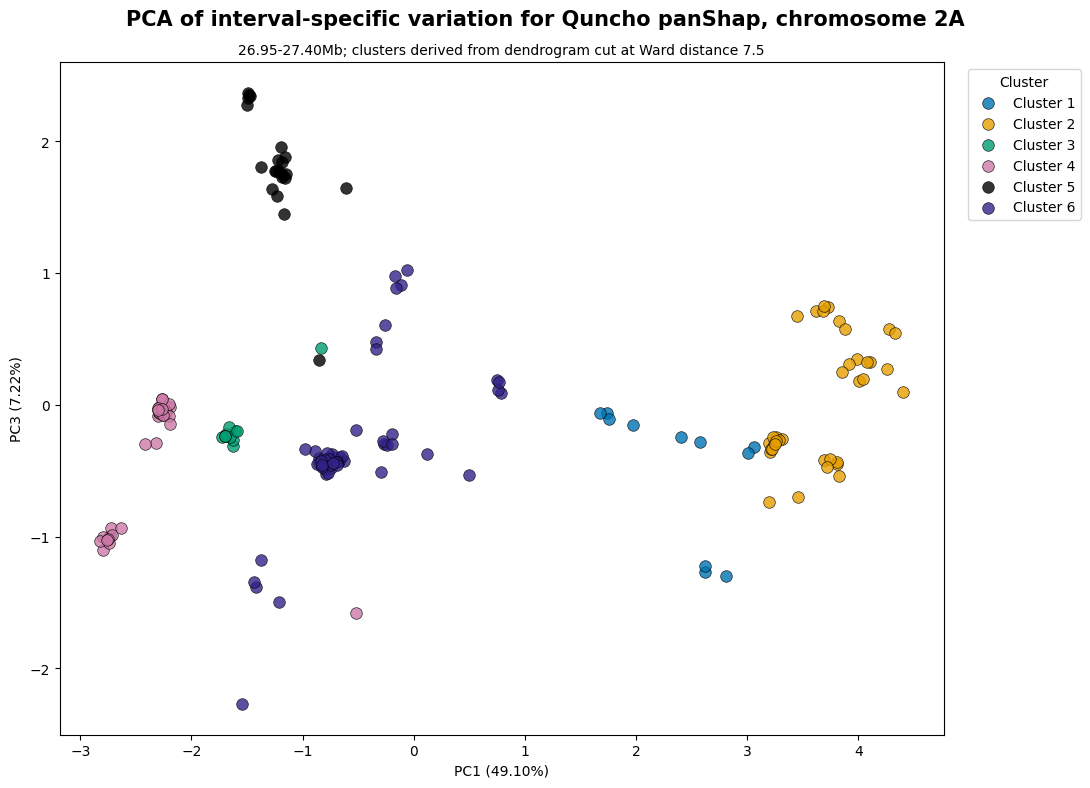

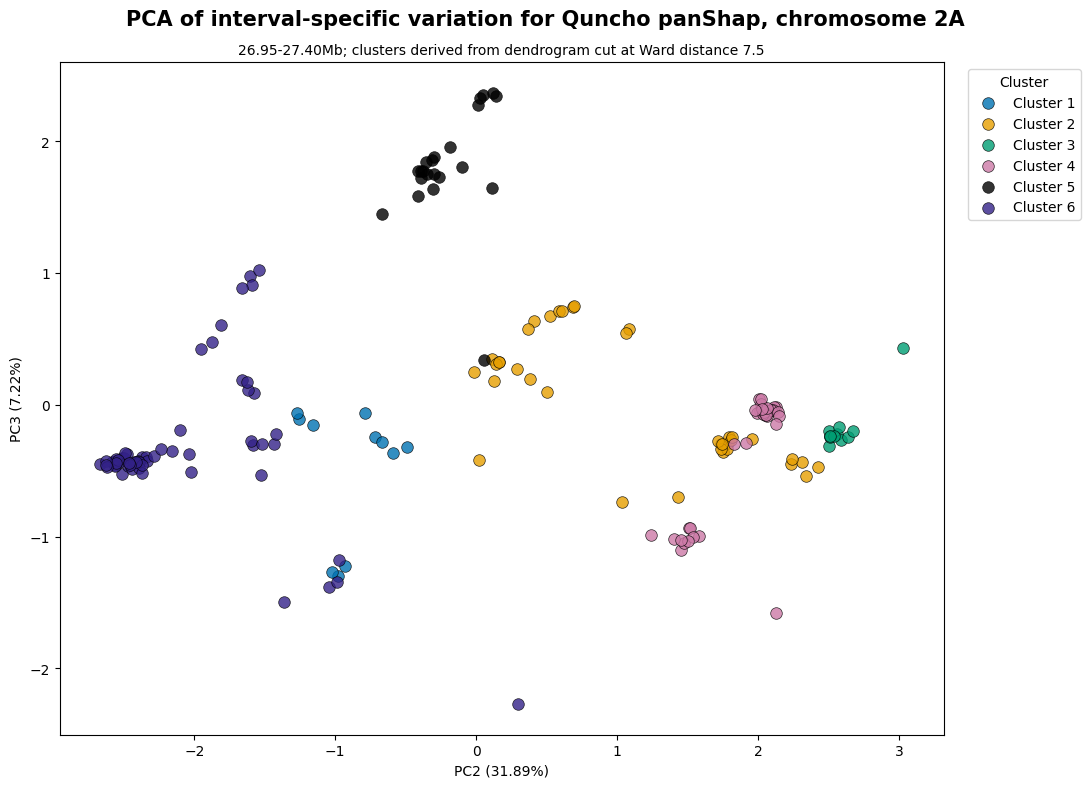

In [271]:
# PC1 versus PC2
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    clusters=clusters,
    unique_clusters=unique_clusters,
    cluster_color_map=cluster_color_map,
    pc_x=0,
    pc_y=1,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

# PC1 versus PC3
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    clusters=clusters,
    unique_clusters=unique_clusters,
    cluster_color_map=cluster_color_map,
    pc_x=0,
    pc_y=2,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

# PC2 versus PC3
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    clusters=clusters,
    unique_clusters=unique_clusters,
    cluster_color_map=cluster_color_map,
    pc_x=1,
    pc_y=2,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

###### =============================================================================
##### 3D PCA PLOT: PC1 vs PC2 vs PC3
###### =============================================================================

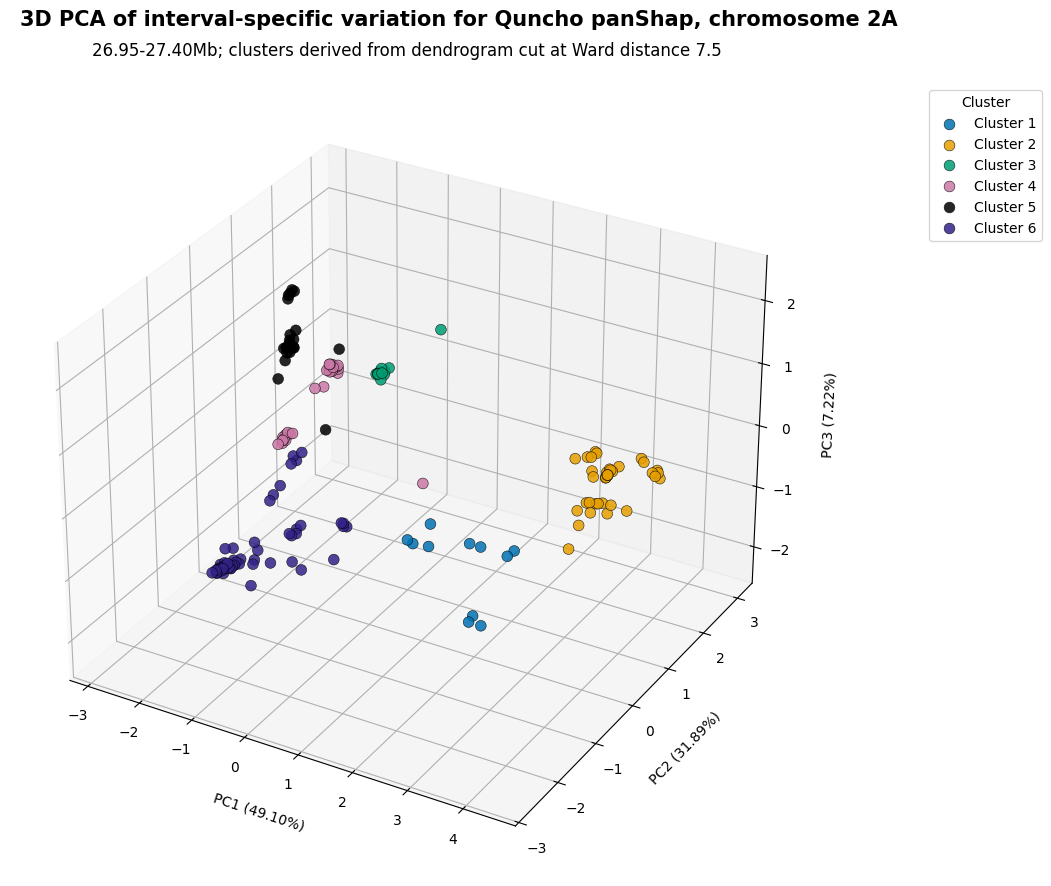

In [272]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# Check that at least 3 principal components were retained.
if PCs.shape[1] >= 3:

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id in unique_clusters:
        cluster_mask = clusters == cluster_id

        ax.scatter(
            PCs[cluster_mask, 0],   # PC1
            PCs[cluster_mask, 1],   # PC2
            PCs[cluster_mask, 2],   # PC3
            color=cluster_color_map[cluster_id],
            edgecolor="black",
            linewidth=0.4,
            s=60,
            alpha=0.85,
            label=f"Cluster {cluster_id}"
        )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)",
        labelpad=10
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)",
        labelpad=10
    )
    ax.set_zlabel(
        f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)",
        labelpad=10
    )

    plt.suptitle(
        f"3D PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    ax.set_title(
        f"{target}; clusters derived from dendrogram cut at "
        f"Ward distance {cut_threshold}",
        pad=20
    )

    ax.legend(
        title="Cluster",
        bbox_to_anchor=(1.15, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PC1_PC2_PC3_3D_cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "Fewer than 3 principal components were retained, "
        "so a 3D PCA plot cannot be generated."
    )

###### =============================================================================
##### SAVE ACCESSION CLUSTER ASSIGNMENTS FOR DOWNSTREAM ANALYSIS
###### =============================================================================

In [273]:
# Create a concise table containing one row per accession.
cluster_assignments = pd.DataFrame(
    {
        "Name": results_df.index.astype(str),
        "reference": genome,
        "trait": trait,
        "chromosome": chromosome,
        "start": start_pos,
        "end": end_pos,
        "analysis_start": analysis_start,
        "analysis_end": analysis_end,
        "cut_threshold": cut_threshold,
        "cluster": clusters
    }
)

# Sort first by cluster and then by accession name.
cluster_assignments = cluster_assignments.sort_values(
    by=["cluster", "Name"]
).reset_index(drop=True)

# Define the output filename.
cluster_assignment_file = os.path.join(
    outDir,
    f"{genome}_{trait}_{chromosome}_"
    f"{start_pos}_{end_pos}_"
    f"cut{cut_threshold}_cluster_assignments.xlsx"
)

# Save the cluster-allocation table.
cluster_assignments.to_excel(
    cluster_assignment_file,
    index=False
)

print(
    f"Cluster assignments saved to: "
    f"{cluster_assignment_file}"
)


Cluster assignments saved to: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-panShap-2A-26980060-27365307/Quncho_panShap_2A_26980060_27365307_cut7.5_cluster_assignments.xlsx


###### =============================================================================
##### COMBINE CLUSTER ASSIGNMENTS ACROSS INTERVALS
###### =============================================================================

In [274]:
# Genome and trait to combine.
workDir="/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis"
target_genome = "Quncho"
target_trait = "panShap"

# All interval-specific output directories for this genome are located here.
genome_dir = os.path.join(
    workDir,
    target_genome
)

if not os.path.isdir(genome_dir):
    raise FileNotFoundError(
        f"Genome directory does not exist: {genome_dir}"
    )

# Recursively locate cluster-assignment Excel files beneath the genome
# directory.
cluster_files = sorted(
    glob.glob(
        os.path.join(
            genome_dir,
            "**",
            "*cluster_assignments.xlsx"
        ),
        recursive=True
    )
)

print(
    f"Found {len(cluster_files)} potential cluster-assignment files "
    f"under: {genome_dir}"
)

Found 35 potential cluster-assignment files under: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho


In [275]:
# Store the interval-specific tables before combining them.
interval_tables = []

# Track interval identifiers to prevent the same interval being added twice.
used_interval_names = set()


for cluster_file in cluster_files:

    print(f"\nChecking: {cluster_file}")

    # Read the cluster-assignment table.
    cluster_df = pd.read_excel(cluster_file)

    # Standardise column names.
    cluster_df.columns = (
        cluster_df.columns
        .astype(str)
        .str.strip()
    )

    # Confirm that the required columns are available.
    required_columns = {
        "Name",
        "reference",
        "trait",
        "chromosome",
        "start",
        "end",
        "cluster",
    }

    missing_columns = required_columns.difference(
        cluster_df.columns
    )

    if missing_columns:
        print(
            f"Skipping file because it is missing columns: "
            f"{sorted(missing_columns)}"
        )
        continue

    # Standardise text columns before filtering.
    for column in [
        "Name",
        "reference",
        "trait",
        "chromosome",
    ]:
        cluster_df[column] = (
            cluster_df[column]
            .astype(str)
            .str.strip()
        )

    # Retain only records corresponding to the requested genome and trait.
    selected = cluster_df[
        (cluster_df["reference"] == target_genome)
        & (cluster_df["trait"] == target_trait)
    ].copy()

    if selected.empty:
        print(
            f"Skipping file because it does not contain "
            f"{target_genome}, {target_trait}."
        )
        continue

    # Confirm that the current file contains one interval only.
    interval_metadata = (
        selected[
            [
                "chromosome",
                "start",
                "end",
            ]
        ]
        .drop_duplicates()
    )

    if len(interval_metadata) != 1:
        raise ValueError(
            f"Expected one interval in {cluster_file}, "
            f"but found {len(interval_metadata)}."
        )

    chromosome = str(
        interval_metadata.iloc[0]["chromosome"]
    )

    start = int(
        interval_metadata.iloc[0]["start"]
    )

    end = int(
        interval_metadata.iloc[0]["end"]
    )

    # Include the coordinates because the same chromosome may contain more
    # than one trait-associated interval.
    interval_name = (
        f"{chromosome}_{start}_{end}"
    )

    # Prevent duplicate interval columns.
    if interval_name in used_interval_names:
        raise ValueError(
            f"Duplicate interval detected: {interval_name}\n"
            f"File: {cluster_file}"
        )

    used_interval_names.add(interval_name)

    # Confirm that every accession occurs only once in the interval.
    duplicated_accessions = selected.loc[
        selected["Name"].duplicated(),
        "Name"
    ].unique()

    if len(duplicated_accessions) > 0:
        raise ValueError(
            f"Duplicate accessions in {cluster_file}: "
            + ", ".join(duplicated_accessions)
        )

    # Retain accession names and cluster assignments.
    interval_df = selected[
        [
            "Name",
            "cluster",
        ]
    ].copy()

    # Rename the cluster column using the chromosome interval.
    interval_df = interval_df.rename(
        columns={
            "cluster": interval_name
        }
    )

    # Use accession identifiers as the index for combining tables.
    interval_df = interval_df.set_index(
        "Name"
    )

    interval_tables.append(
        interval_df
    )

    print(
        f"Added {interval_name}: "
        f"{len(interval_df)} accessions"
    )
    
    # Stop if no matching files were found.
if not interval_tables:
    raise ValueError(
        f"No matching cluster-assignment tables were found for "
        f"genome '{target_genome}' and trait '{target_trait}' "
        f"under {genome_dir}."
    )




Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-dth-2B-7713036-7808328/Quncho_dth_2B_7713036_7808328_cut5_cluster_assignments.xlsx
Skipping file because it does not contain Quncho, panShap.

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-dth-6A-21548546-21737052/Quncho_dth_6A_21548546_21737052_cut15_cluster_assignments.xlsx
Skipping file because it does not contain Quncho, panShap.

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-dth-8B-7975058-8198154/Quncho_dth_8B_7975058_8198154_cut5_cluster_assignments.xlsx
Skipping file because it does not contain Quncho, panShap.

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-dth-9A-5839259-5979171/Quncho_dth_9A_5839259_5979171_cut5_cluster_assignments.xlsx
Skipping file because it does not contain Quncho, panShap.

Checking: /Users/waweru/Documents/2022/202

In [276]:
# =============================================================================
# COMBINE THE INTERVAL TABLES
# =============================================================================

# Use an outer join so that all accessions are retained even when an accession
# is absent from one interval.
combined_clusters = pd.concat(
    interval_tables,
    axis=1,
    join="outer"
)

# Sort accession identifiers alphabetically.
combined_clusters = (
    combined_clusters
    .sort_index()
    .reset_index()
)

# Ensure the accession column is explicitly named "Name".
combined_clusters = combined_clusters.rename(
    columns={
        combined_clusters.columns[0]: "Name"
    }
)


In [277]:
combined_clusters.head()

,Name,10A_2490690_2588834,1B_24610690_24723221,2A_26980060_27365307,2A_27057228_27278503,2B_1941873_2057114,2B_7866255_7961677,3B_30384826_30455026,4B_13392258_13874501,4B_13599121_13723793,6A_6227571_6412251,8A_8139941_8777893
0,Boni,6,4,6,5,3,3,1,2,1,2,8
1,DZ,3,4,3,3,4,3,4,1,2,2,8
2,Dabbi,6,1,2,1,2,3,2,3,1,2,7
3,Dtt2-02,6,4,4,4,3,3,1,2,1,2,8
4,Quncho,6,1,6,5,5,3,3,1,2,1,2


In [278]:
# =============================================================================
# SAVE THE COMBINED CLUSTER TABLE
# =============================================================================

combined_output_file = os.path.join(
    workDir,
    f"{target_genome}_{target_trait}_"
    f"combined_cluster_assignments.xlsx"
)

combined_clusters.to_excel(
    combined_output_file,
    index=False
)

print(
    f"\nCombined cluster-assignment table saved to:\n"
    f"{combined_output_file}"
)

print(
    f"\nCombined table contains "
    f"{combined_clusters.shape[0]} accessions and "
    f"{combined_clusters.shape[1] - 1} intervals."
)

display(
    combined_clusters.head()
)


Combined cluster-assignment table saved to:
/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho_panShap_combined_cluster_assignments.xlsx

Combined table contains 177 accessions and 11 intervals.


,Name,10A_2490690_2588834,1B_24610690_24723221,2A_26980060_27365307,2A_27057228_27278503,2B_1941873_2057114,2B_7866255_7961677,3B_30384826_30455026,4B_13392258_13874501,4B_13599121_13723793,6A_6227571_6412251,8A_8139941_8777893
0,Boni,6,4,6,5,3,3,1,2,1,2,8
1,DZ,3,4,3,3,4,3,4,1,2,2,8
2,Dabbi,6,1,2,1,2,3,2,3,1,2,7
3,Dtt2-02,6,4,4,4,3,3,1,2,1,2,8
4,Quncho,6,1,6,5,5,3,3,1,2,1,2
